In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split
import seaborn as sns
pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
data_2015 = pd.read_csv(os.path.join('/Users/pizza_machine/Desktop/Sandia/CHAIN_SVM_scintillationPrediction/6813131/','ml_db_2015_NaNsDropped.csv'))
data_2015 = data_2015.drop(data_2015.columns[0], axis=1)
y_2015 = data_2015['sigmaPhi projected to vertical at prediction time [radians]'].values
print(f'2015 data length: {len(y_2015)}')


X_fSelect = data_2015.drop('sigmaPhi projected to vertical at prediction time [radians]', axis=1)
X_fSelect = X_fSelect.values

training_data_size = 50000
test_data_size = 4365846

X_train, X_test, \
    y_train, y_test, \
        idx_train, idx_test = train_test_split(X_fSelect, y_2015, range(len(y_2015)), train_size=training_data_size, shuffle=False)
X_val, X_test, \
    y_val, y_test, \
        idx_val, idx_test = train_test_split(X_test, y_test, range(len(y_test)), test_size=test_data_size, shuffle=False)

2015 data length: 4465846


In [3]:
data_2015.columns

Index(['index', 'datetime', 'doy', 'ut', 'azimuth [deg]', 'elevation [deg]',
       'CHAIN station', 'CHAIN station model', 'CHAIN station ID number',
       'Bz - 30min [nT]', 'Bz - 15min [nT]', 'Bz - 0min [nT]',
       'By - 30min [nT]', 'By - 15min [nT]', 'By - 0min [nT]',
       'Vsw - 30min [km/s]', 'Vsw - 15min [km/s]', 'Vsw - 0min [km/s]',
       'Psw - 30min [nPa]', 'Psw - 15min [nPa]', 'Psw - 0min [nPa]',
       'AE - 30min [nT]', 'AE - 15min [nT]', 'AE - 0min [nT]',
       'SymH - 30min [nT]', 'SymH - 15min [nT]', 'SymH - 0min [nT]',
       'Clock Angle - 30min [deg]', 'Clock Angle - 15min [deg]',
       'Clock Angle - 0min [deg]', 'Newell CF - 30min [m/s^(4/3) T^(2/3)]',
       'Newell CF - 15min [m/s^(4/3) T^(2/3)]',
       'Newell CF - 0min [m/s^(4/3) T^(2/3)]', 'Borovsky CF - 30min [nT km/s]',
       'Borovsky CF - 15min [nT km/s]', 'Borovsky CF - 0min [nT km/s]',
       'Kp [dimensionless]', 'F107 [sfu=10^-22 W/m^2/hz]',
       'OVATION diffuse eflux [erg/cm^2/s]', 'OVAT

In [4]:
# data_2015[['datetime','CHAIN station','sigmaPhi projected to vertical at prediction time [radians]']]
seq_df = data_2015[['datetime','CHAIN station']]
seq_df

,datetime,CHAIN station
0,2015-01-01 00:01:00,arv
1,2015-01-01 00:02:00,arv
2,2015-01-01 00:03:00,arv
3,2015-01-01 00:04:00,arv
4,2015-01-01 00:05:00,arv
...,...,...
4465841,2015-12-31 22:45:00,rep
4465842,2015-12-31 22:46:00,rep
4465843,2015-12-31 22:47:00,rep
4465844,2015-12-31 22:58:00,rep


In [5]:
seq_df['datetime'] = pd.to_datetime(seq_df['datetime'])
seq_df['station_change'] = seq_df['CHAIN station'] != seq_df['CHAIN station'].shift(1)
seq_df['sequence_group'] = seq_df.groupby('CHAIN station')['station_change'].cumsum()
sequence_lengths = seq_df.groupby(['CHAIN station', 'sequence_group']).size().reset_index(name='sequence_length')

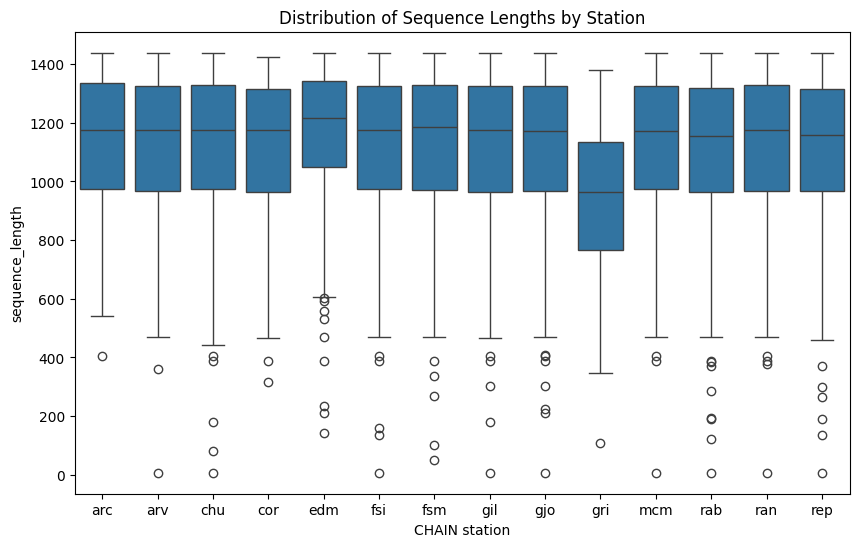

     CHAIN station  sequence_group  sequence_length
3373           ran              29                7
2696           mcm              29                7
3044           rab              29                7
1300           fsi              29                7
1976           gil              29                7
2317           gjo              29                7
3719           rep              29                7
534            chu              29                7
187            arv              29                7
1840           fsm             221               51
532            chu              27               80
1747           fsm             128              100
2667           gri              54              109
3221           rab             206              122
1312           fsi              41              136
3788           rep              98              137
1116           edm              26              143
1339           fsi              68              160
2158        

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

seq_df['datetime'] = pd.to_datetime(seq_df['datetime'])
seq_df['station_change'] = seq_df['CHAIN station'] != seq_df['CHAIN station'].shift(1)
seq_df['sequence_group'] = seq_df.groupby('CHAIN station')['station_change'].cumsum()
sequence_lengths = seq_df.groupby(['CHAIN station', 'sequence_group']).size().reset_index(name='sequence_length')

plt.figure(figsize=(10, 6))
sns.boxplot(x='CHAIN station', y='sequence_length', data=sequence_lengths)
plt.title('Distribution of Sequence Lengths by Station')
plt.show()

print(sequence_lengths.sort_values(by=['sequence_length'], ascending=True).head(20))


In [12]:
data_2015['CHAIN station']

0          arv
1          arv
2          arv
3          arv
4          arv
          ... 
4465841    rep
4465842    rep
4465843    rep
4465844    rep
4465845    rep
Name: CHAIN station, Length: 4465846, dtype: object

In [15]:
# test_station_2015 = pd.DataFrame(data_2015['CHAIN station'], columns=['CHAIN station'])
# test_station_2015.to_csv("2015_test_station_4365846.csv")
# test_station_2015

,CHAIN station
0,arv
1,arv
2,arv
3,arv
4,arv
...,...
4465841,rep
4465842,rep
4465843,rep
4465844,rep


In [35]:
test_datetime_2015 = pd.DataFrame(X_test[:,1], columns=['datetime'])
test_datetime_2015['datetime'] = pd.to_datetime(test_datetime_2015['datetime'])
test_datetime_2015['predicted_datetime'] = test_datetime_2015['datetime'] + pd.Timedelta(hours=1)
# test_datetime_2015.to_csv("2015_test_datetime_4365846.csv")
test_datetime_2015

,datetime,predicted_datetime
0,2015-01-07 04:28:00,2015-01-07 05:28:00
1,2015-01-07 04:29:00,2015-01-07 05:29:00
2,2015-01-07 04:30:00,2015-01-07 05:30:00
3,2015-01-07 04:31:00,2015-01-07 05:31:00
4,2015-01-07 04:32:00,2015-01-07 05:32:00
...,...,...
4365841,2015-12-31 22:45:00,2015-12-31 23:45:00
4365842,2015-12-31 22:46:00,2015-12-31 23:46:00
4365843,2015-12-31 22:47:00,2015-12-31 23:47:00
4365844,2015-12-31 22:58:00,2015-12-31 23:58:00


In [36]:
test_datetime_2015['time_difference_hours'] = \
(test_datetime_2015['predicted_datetime'] - \
 test_datetime_2015['datetime']).dt.total_seconds() / 3600
test_datetime_2015

,datetime,predicted_datetime,time_difference_hours
0,2015-01-07 04:28:00,2015-01-07 05:28:00,1.0
1,2015-01-07 04:29:00,2015-01-07 05:29:00,1.0
2,2015-01-07 04:30:00,2015-01-07 05:30:00,1.0
3,2015-01-07 04:31:00,2015-01-07 05:31:00,1.0
4,2015-01-07 04:32:00,2015-01-07 05:32:00,1.0
...,...,...,...
4365841,2015-12-31 22:45:00,2015-12-31 23:45:00,1.0
4365842,2015-12-31 22:46:00,2015-12-31 23:46:00,1.0
4365843,2015-12-31 22:47:00,2015-12-31 23:47:00,1.0
4365844,2015-12-31 22:58:00,2015-12-31 23:58:00,1.0


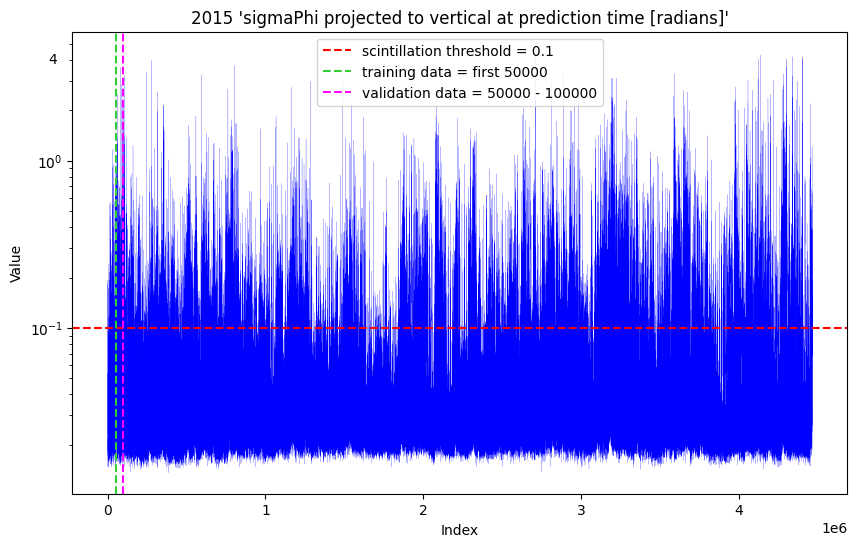

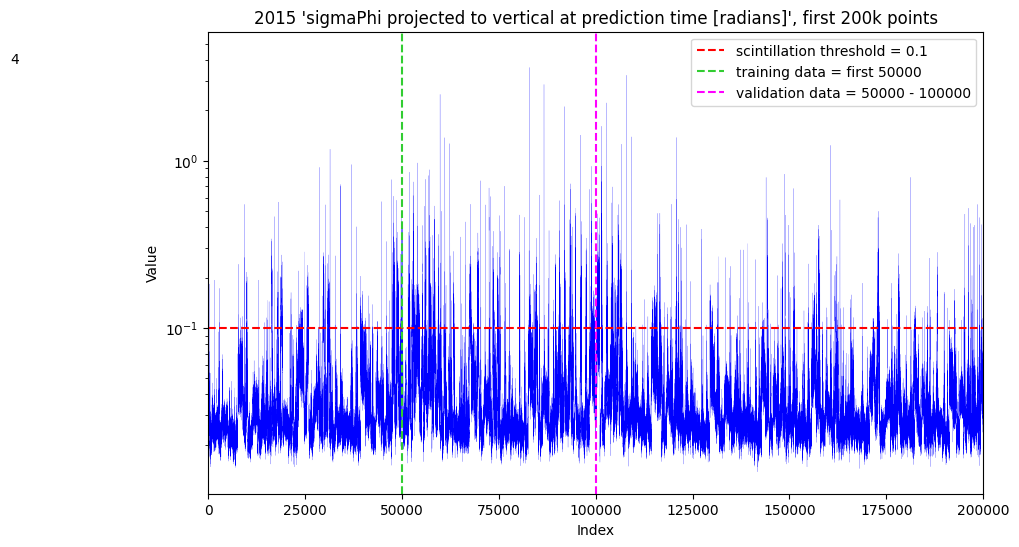

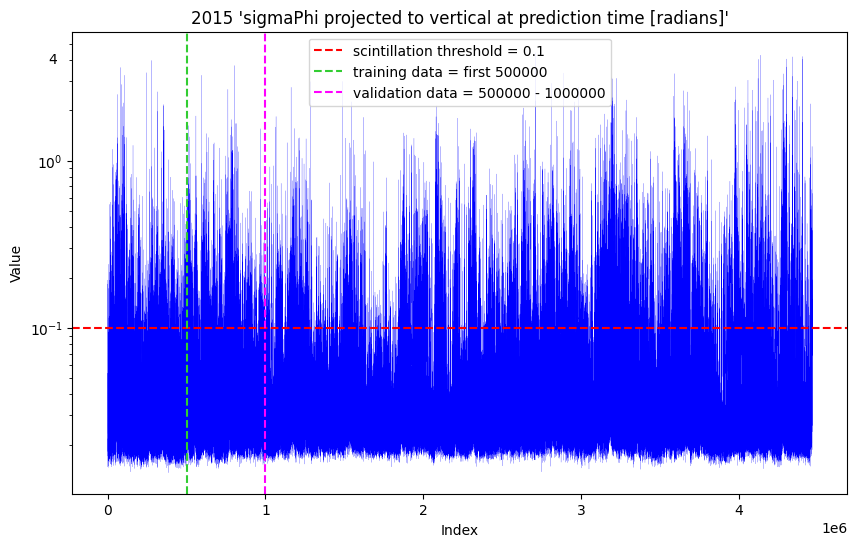

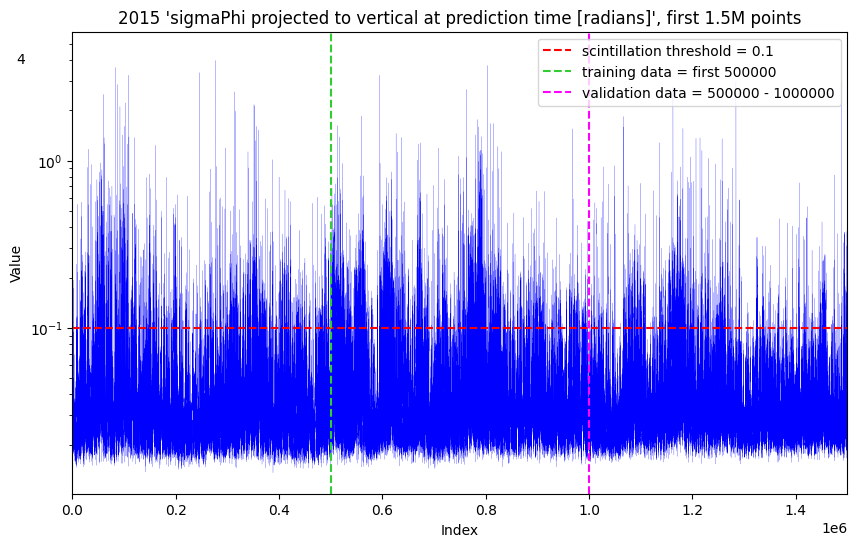

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(y_2015, color='blue', lw=0.1) 
plt.axhline(y=0.1, color='red', linestyle='--', label='scintillation threshold = 0.1')
plt.axvline(x=50000, color='limegreen', linestyle='--', label='training data = first 50000')
plt.axvline(x=100000, color='magenta', linestyle='--', label='validation data = 50000 - 100000')
plt.title("2015 'sigmaPhi projected to vertical at prediction time [radians]'")
plt.xlabel('Index')
plt.ylabel('Value')
plt.yscale('log')
plt.text(-350000, 4, '4', color='black', fontsize=10, ha='center', va='center')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(y_2015, color='blue', lw=0.1) 
plt.axhline(y=0.1, color='red', linestyle='--', label='scintillation threshold = 0.1')
plt.axvline(x=50000, color='limegreen', linestyle='--', label='training data = first 50000')
plt.axvline(x=100000, color='magenta', linestyle='--', label='validation data = 50000 - 100000')
plt.title("2015 'sigmaPhi projected to vertical at prediction time [radians]', first 200k points")
plt.xlabel('Index')
plt.ylabel('Value')
plt.yscale('log')
plt.text(-50000, 4, '4', color='black', fontsize=10, ha='center', va='center')
plt.xlim(0, 200000)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(y_2015, color='blue', lw=0.1) 
plt.axhline(y=0.1, color='red', linestyle='--', label='scintillation threshold = 0.1')
plt.axvline(x=500000, color='limegreen', linestyle='--', label='training data = first 500000')
plt.axvline(x=1000000, color='magenta', linestyle='--', label='validation data = 500000 - 1000000')
plt.title("2015 'sigmaPhi projected to vertical at prediction time [radians]'")
plt.xlabel('Index')
plt.ylabel('Value')
plt.yscale('log')
plt.text(-350000, 4, '4', color='black', fontsize=10, ha='center', va='center')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(y_2015, color='blue', lw=0.1) 
plt.axhline(y=0.1, color='red', linestyle='--', label='scintillation threshold = 0.1')
plt.axvline(x=500000, color='limegreen', linestyle='--', label='training data = first 500000')
plt.axvline(x=1000000, color='magenta', linestyle='--', label='validation data = 500000 - 1000000')
plt.title("2015 'sigmaPhi projected to vertical at prediction time [radians]', first 1.5M points")
plt.xlabel('Index')
plt.ylabel('Value')
plt.yscale('log')
plt.text(-100000, 4, '4', color='black', fontsize=10, ha='center', va='center')
plt.xlim(0, 1500000)
plt.legend()
plt.show()

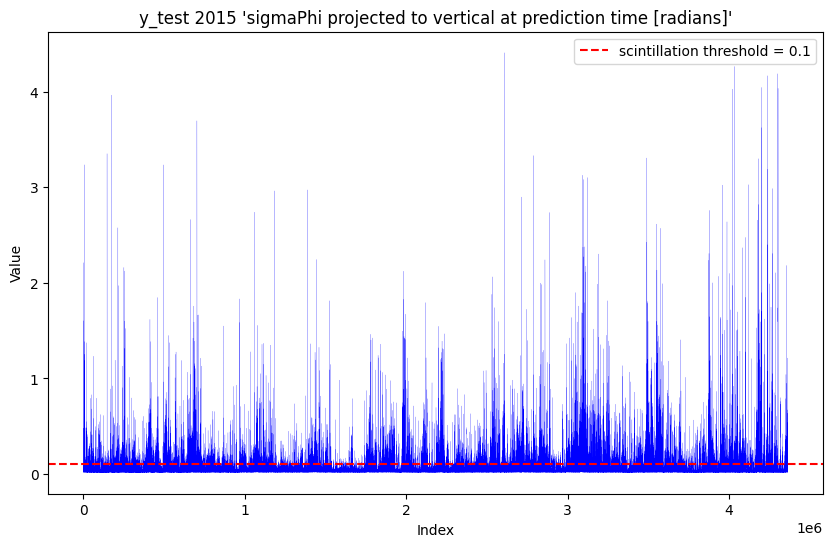

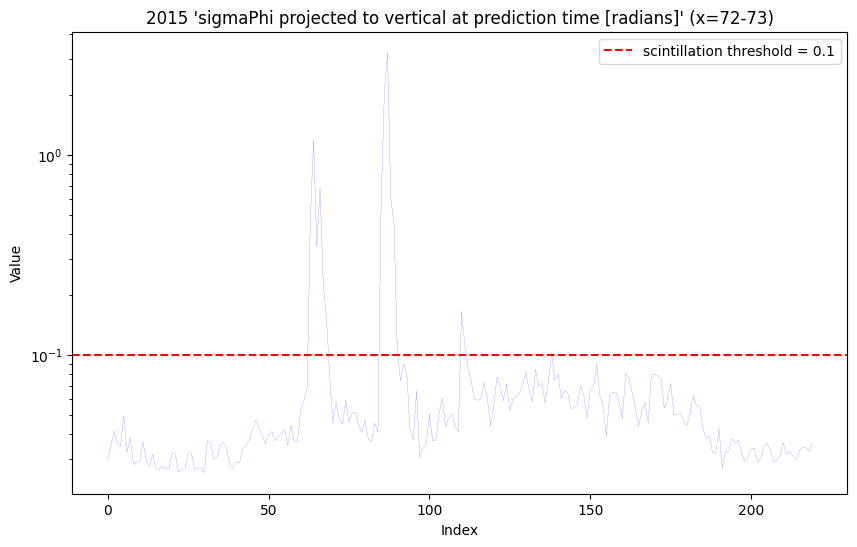

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(y_test, color='blue', lw=0.1) 
plt.axhline(y=0.1, color='red', linestyle='--', label='scintillation threshold = 0.1')
plt.title("y_test 2015 'sigmaPhi projected to vertical at prediction time [radians]'")
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.show()

# def plot_sequence(y, x):
#     start = x * 110
#     end = start + 110
#     plt.figure(figsize=(10, 6))
#     plt.plot(y[start:end], color='blue', lw=0.1)
#     plt.axhline(y=0.1, color='red', linestyle='--', label='scintillation threshold = 0.1')
#     plt.title(f"2015 'sigmaPhi projected to vertical at prediction time [radians]' (x={x})")
#     plt.xlabel('Index')
#     plt.ylabel('Value')
#     plt.legend()
#     plt.show()

# plot_sequence(y_test, 72)

from matplotlib.ticker import LogLocator, LogFormatter

def plot_sequence_range(y, x_range):
    all_data = []
    
    for x in x_range:
        start = x * 110
        end = start + 110
        all_data.append(y[start:end])
    
    all_data_concatenated = np.concatenate(all_data, axis=0)

    plt.figure(figsize=(10, 6))
    plt.plot(all_data_concatenated, color='blue', lw=0.1)
    plt.axhline(y=0.1, color='red', linestyle='--', label='scintillation threshold = 0.1')
    plt.title(f"2015 'sigmaPhi projected to vertical at prediction time [radians]' (x={x_range[0]}-{x_range[-1]})")
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.yscale('log')

    # plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.1, 1.0), numticks=10))
    # plt.gca().yaxis.set_major_formatter(LogFormatter(labelOnlyBase=False))
    
    plt.legend()
    plt.show()

plot_sequence_range(y_test, range(72, 74))



In [6]:
pd.DataFrame(y_test, columns=['sigmaPhi projected to vertical at prediction time [radians]']).to_csv("2015_y_test_4365846.csv")

In [ ]:
ml_db_o_2016 = pd.read_csv(os.path.join('/Users/pizza_machine/Desktop/Sandia/CHAIN_SVM_scintillationPrediction/6813131/','ml_db_2016_NaNsDropped.csv'))
ml_db_2016 = ml_db_o_2016.copy()

# Drop two saved index columns
ml_db_2016 = ml_db_2016.drop(columns=ml_db_2016.columns[0:1]) 

date_limits = [datetime.datetime(2016,1,15), datetime.datetime(2016,1,25)]
doy_limits = [date_limits[0].timetuple().tm_yday, date_limits[1].timetuple().tm_yday]
doy_mask_Jan15 = (ml_db_2016['doy']>=doy_limits[0])
doy_mask_Jan25 = (ml_db_2016['doy']<=doy_limits[1])

ml_db_2016 = ml_db_2016[ doy_mask_Jan15 & doy_mask_Jan25 ]

print(np.shape(ml_db_2016))

In [8]:
# data_2016 = pd.read_csv(os.path.join('/Users/pizza_machine/Desktop/Sandia/CHAIN_SVM_scintillationPrediction/6813131/','ml_db_2016_NaNsDropped.csv'))
# y_2016 = data_2016['sigmaPhi projected to vertical at prediction time [radians]'].values
# print(f'2016 data length: {len(y_2016)}')


In [9]:
# plt.figure(figsize=(10, 6))
# plt.plot(y_2016, color='blue', lw=0.1) 
# plt.axhline(y=0.1, color='red', linestyle='--', label='scintillation threshold = 0.1')
# plt.title("2016 'sigmaPhi projected to vertical at prediction time [radians]'")
# plt.xlabel('Index')
# plt.ylabel('Value')
# plt.legend()
# plt.show()

# plt.figure(figsize=(10, 6))
# plt.plot(y_2016, color='blue', lw=0.1) 
# plt.axhline(y=0.1, color='red', linestyle='--', label='scintillation threshold = 0.1')
# plt.title("2016 'sigmaPhi projected to vertical at prediction time [radians]', first 200k points")
# plt.xlabel('Index')
# plt.ylabel('Value')
# plt.xlim(0, 200000)
# plt.legend()
# plt.show()

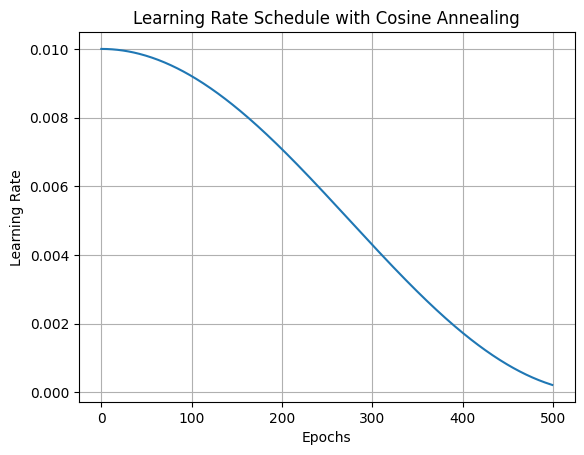

[np.float64(0.01), np.float64(0.009999918433243252), np.float64(0.009999673735634259), np.float64(0.009999265915156697), np.float64(0.009998694985116404), np.float64(0.009997960964140946), np.float64(0.009997063876179007), np.float64(0.009996003750499607), np.float64(0.009994780621691155), np.float64(0.009993394529660306), np.float64(0.009991845519630678), np.float64(0.009990133642141357), np.float64(0.009988258953045264), np.float64(0.009986221513507318), np.float64(0.009984021390002458), np.float64(0.009981658654313457), np.float64(0.00997913338352859), np.float64(0.009976445660039118), np.float64(0.009973595571536592), np.float64(0.009970583211010006), np.float64(0.009967408676742751), np.float64(0.009964072072309411), np.float64(0.00996057350657239), np.float64(0.009956913093678348), np.float64(0.00995309095305449), np.float64(0.009949107209404664), np.float64(0.009944961992705286), np.float64(0.009940655438201112), np.float64(0.009936187686400814), np.float64(0.009931558883072402)

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
epochs = 500
T_max = 550
initial_lr = 0.01

# Calculate learning rate at each epoch using Cosine Annealing Formula
lr_values = [initial_lr * 0.5 * (1 + np.cos(np.pi * epoch / T_max)) for epoch in range(epochs)]

# Plot the learning rate across epochs
plt.plot(range(epochs), lr_values, label="Learning Rate")
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule with Cosine Annealing')
plt.grid(True)
plt.show()

# Print the learning rates for each epoch
print(lr_values)
